# Análisis de Machine Learning - Cartera S&P 500

## Objetivo
Aplicar técnicas de Machine Learning sobre las 242 empresas candidatas
seleccionadas en la fase SQL para identificar patrones, agrupar empresas
por perfil financiero y predecir su comportamiento.

## Técnicas aplicadas
- **PCA** (Análisis de Componentes Principales): reducción de dimensionalidad
- **K-Means**: agrupación de empresas por perfil financiero similar
- **Regresión Lineal**: predicción de rentabilidad basada en KPIs

## Dataset
- Fuente: tabla `empresas_candidatas` exportada desde PostgreSQL
- Registros: 242 empresas
- Variables: ROE, Net Profit Margin, Debt to Equity, PE Ratio, Revenue Growth

In [1]:
import pandas as pd

# Cargamos las empresas candidatas
df = pd.read_csv('empresas_candidatas.csv')

print(f"Empresas candidatas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Empresas candidatas: 242
Columnas: 7


,ticker,sector,roe,net_profit_margin,debt_to_equity,pe_ratio,revenue_growth
0,CENX,Basic Materials,0.1144,0.0655,0.2305,18.6260,0.3278
1,CE,Basic Materials,0.2214,0.0917,0.9663,14.8784,0.0449
2,SLCA,Basic Materials,0.3010,0.1386,1.2260,11.3673,0.6058
3,LYB,Basic Materials,0.5020,0.0915,0.8474,9.8867,0.0351
4,MEOH,Basic Materials,0.2545,0.1410,0.9971,9.5678,0.0659


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Seleccionamos solo las columnas numéricas (los KPIs)
kpis = ['roe', 'net_profit_margin', 'debt_to_equity', 'pe_ratio', 'revenue_growth']

X = df[kpis]

# Estandarizamos: media 0 y desviación estándar 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados correctamente")
print(f"Forma del dataset: {X_scaled.shape}")

Datos estandarizados correctamente
Forma del dataset: (242, 5)


## 1. PCA - Análisis de Componentes Principales

El PCA reduce las 5 variables (KPIs) a componentes principales que
capturan la mayor parte de la varianza de los datos. Esto nos permite
visualizar las 242 empresas en 2 dimensiones manteniendo la mayor
información posible.

In [4]:
# Aplicamos PCA con 2 componentes para poder visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada por cada componente
varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por componente 1: {varianza[0]:.2%}")
print(f"Varianza explicada por componente 2: {varianza[1]:.2%}")
print(f"Varianza total explicada: {sum(varianza):.2%}")

Varianza explicada por componente 1: 28.41%
Varianza explicada por componente 2: 26.59%
Varianza total explicada: 55.00%


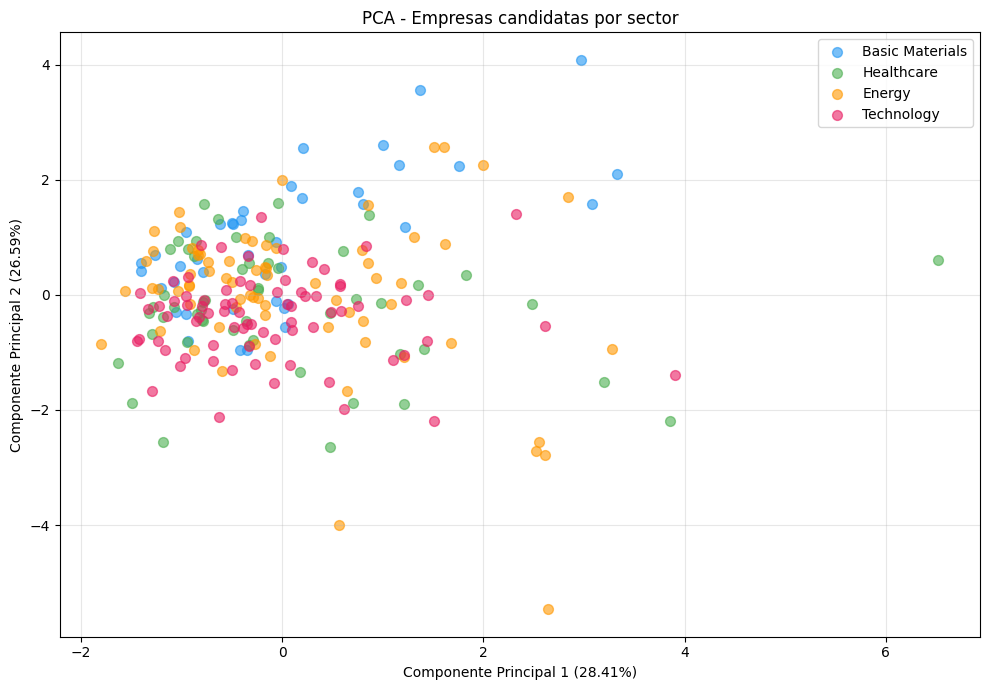

In [5]:
# Visualizamos las empresas en el espacio PCA coloreadas por sector
plt.figure(figsize=(10, 7))

sectores = df['sector'].unique()
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for sector, color in zip(sectores, colores):
    mask = df['sector'] == sector
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=sector, color=color, alpha=0.6, s=50)

plt.xlabel(f'Componente Principal 1 ({varianza[0]:.2%})')
plt.ylabel(f'Componente Principal 2 ({varianza[1]:.2%})')
plt.title('PCA - Empresas candidatas por sector')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. K-Means - Agrupación de empresas por perfil financiero

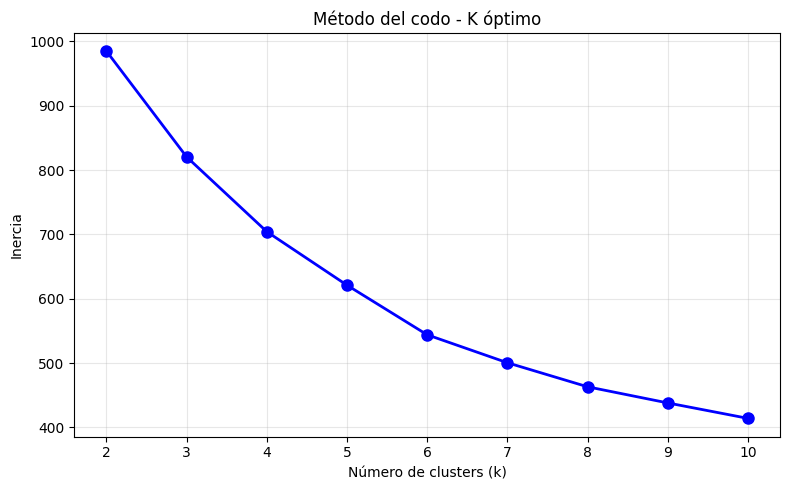

In [6]:
# Determinamos el número óptimo de clusters con el método del codo
inercias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inercias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo - K óptimo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

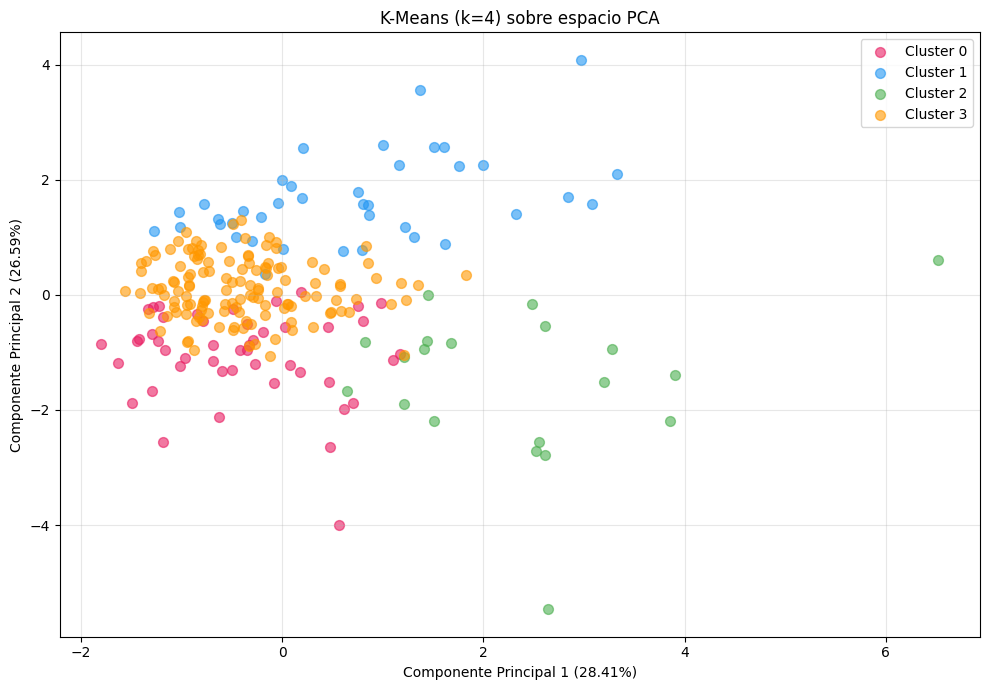

In [7]:
# Aplicamos K-Means con k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Añadimos el cluster asignado al dataframe original
df['cluster'] = kmeans.labels_

# Visualizamos los clusters en el espacio PCA
plt.figure(figsize=(10, 7))

colores_cluster = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']

for cluster, color in zip(range(4), colores_cluster):
    mask = df['cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}',
                color=color, alpha=0.6, s=50)

plt.xlabel(f'Componente Principal 1 ({varianza[0]:.2%})')
plt.ylabel(f'Componente Principal 2 ({varianza[1]:.2%})')
plt.title('K-Means (k=4) sobre espacio PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Perfil medio de cada cluster
perfil_clusters = df.groupby('cluster')[kpis].mean().round(4)
print(perfil_clusters)

            roe  net_profit_margin  debt_to_equity  pe_ratio  revenue_growth
cluster                                                                     
0        0.1742             0.1621          0.2530   36.6008          0.2726
1        0.3007             0.1602          1.2966   17.4589          0.1462
2        0.2232             0.3739          0.3899   18.5705          0.9436
3        0.1622             0.1566          0.3550   17.3743          0.1526


In [9]:
# Distribución de sectores por cluster
distribucion = pd.crosstab(df['cluster'], df['sector'])
print(distribucion)

sector   Basic Materials  Energy  Healthcare  Technology
cluster                                                 
0                      5       5          15          23
1                     17      13           6           3
2                      0       9           6           5
3                     19      45          26          45


## 3. Regresión Lineal — Predicción de rentabilidad

Usamos regresión lineal múltiple para predecir el ROE de una empresa
a partir del resto de KPIs financieros. Esto nos permite entender
qué variables influyen más en la rentabilidad.

In [10]:
from sklearn.model_selection import train_test_split

# Variable objetivo: ROE
# Variables predictoras: el resto de KPIs
X_reg = df[['net_profit_margin', 'debt_to_equity', 'pe_ratio', 'revenue_growth']]
y_reg = df['roe']

# Dividimos en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Empresas para entrenamiento: {X_train.shape[0]}")
print(f"Empresas para test: {X_test.shape[0]}")

Empresas para entrenamiento: 193
Empresas para test: 49


In [11]:
# Entrenamos el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes del modelo
print("Intercepto:", round(model.intercept_, 4))
print("\nCoeficientes:")
for nombre, coef in zip(X_reg.columns, model.coef_):
    print(f"  {nombre}: {round(coef, 4)}")

Intercepto: 0.1141

Coeficientes:
  net_profit_margin: 0.4211
  debt_to_equity: 0.0535
  pe_ratio: -0.0005
  revenue_growth: -0.0491


In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predicciones sobre el conjunto de test
y_pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²:  {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

R²:  0.1138
MSE: 0.0147
MAE: 0.0725


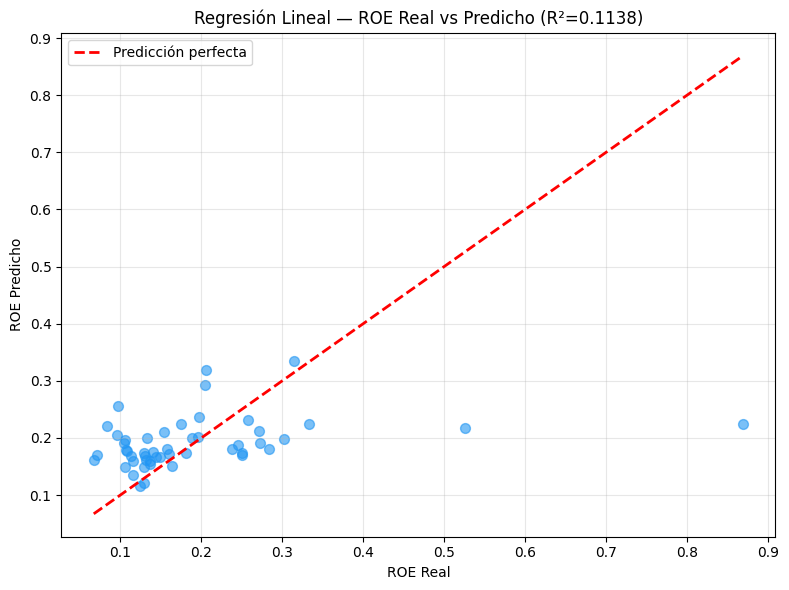

In [13]:
# Visualización: ROE real vs ROE predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#2196F3', s=50)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('ROE Real')
plt.ylabel('ROE Predicho')
plt.title(f'Regresión Lineal — ROE Real vs Predicho (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones del bloque de Machine Learning

### PCA
La reducción dimensional a 2 componentes principales captura el 55%
de la varianza total de los KPIs financieros. La distribución de las
empresas en el espacio PCA muestra que los sectores no se separan
de forma nítida, lo que indica que el perfil financiero de una empresa
cruza fronteras sectoriales.

### K-Means (k=4)
El análisis de clustering identifica 4 perfiles financieros diferenciados:
- **Cluster 0** — Crecimiento con valoración alta (PE ratio elevado)
- **Cluster 1** — Rentabilidad con apalancamiento
- **Cluster 2** — Estrellas de crecimiento excepcional
- **Cluster 3** — Perfil conservador y estable (grupo mayoritario)

### Regresión Lineal
El modelo obtiene un R²=0.1138 y un MAE=0.0725, lo que refleja
la naturaleza multifactorial del ROE — influido por factores cualitativos
no recogidos en el dataset. Sin embargo, el modelo predice con
razonable precisión empresas con ROE moderado, lo que lo hace
especialmente útil para un perfil inversor conservador que busca
empresas predecibles y estables, evitando las de comportamiento
más extremo.